# Session 8

In [1]:
# ---
# jupyter:
#   jupytext:
#     formats: ipynb,py
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: '1.16.0'
# ---

In [2]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

In [3]:
# %%
import os
print(os.getcwd())

/home/mukh11/mukh11


In [4]:
# %%
import os
print(os.listdir())

['.pytest_cache', '.ipynb_checkpoints', 'session5.py', 'README.md', 'session8-data.tar.gz', 'session5.ipynb', 'CITATION.cff', 'fmri-data', 'tests', 'doc', '.flake8', 'session5_peaks.ipynb', 'spacemed.yml', 'heart_rate.pdf', 'notebooks', 'src', 'session8.py', 'setup.cfg', '.gitignore', 'pyproject.toml', 'data', '.git', 'setup.py', 'fmri-data.tar.gz', 'session5_peaks.py', 'session8.ipynb']


In [5]:
# %%
import tarfile

with tarfile.open("fmri-data.tar.gz") as tar:
    for name in tar.getnames():
        print(name)

fmri-data/1_Localizer_1.5mm_15s.nii
fmri-data/2_Anatomy_1mm_5min.nii
fmri-data/3_fMRI_TR2sec_3mm_3min.nii
fmri-data/4_fMRI_blobs.nii
fmri-data/README.md


In [6]:
# %%
with tarfile.open("fmri-data.tar.gz") as tar:
    tar.extractall()

/tmp/ipykernel_557064/3926829134.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [7]:
# %%
import os

print(os.listdir())

['.pytest_cache', '.ipynb_checkpoints', 'session5.py', 'README.md', 'session8-data.tar.gz', 'session5.ipynb', 'CITATION.cff', 'fmri-data', 'tests', 'doc', '.flake8', 'session5_peaks.ipynb', 'spacemed.yml', 'heart_rate.pdf', 'notebooks', 'src', 'session8.py', 'setup.cfg', '.gitignore', 'pyproject.toml', 'data', '.git', 'setup.py', 'fmri-data.tar.gz', 'session5_peaks.py', 'session8.ipynb']


In [8]:
# %%
print(os.listdir("fmri-data"))

['README.md', '3_fMRI_TR2sec_3mm_3min.nii', '1_Localizer_1.5mm_15s.nii', '2_Anatomy_1mm_5min.nii', '4_fMRI_blobs.nii']


In [9]:
# %%
fmri = nib.load("fmri-data/3_fMRI_TR2sec_3mm_3min.nii")
print(fmri.shape)

(64, 64, 32, 80)


In [10]:
# Coverting to NumPy array
# %%
data = fmri.get_fdata()

print(data.shape)

(64, 64, 32, 80)


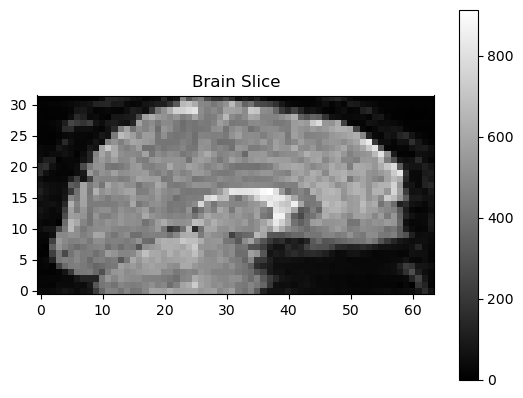

In [11]:
# Visualizing brain slices
# %%
plt.imshow(data[30, :, :, 0].T, cmap="gray", origin="lower")
plt.title("Brain Slice")
plt.colorbar()
plt.show()

In [12]:
print(data.shape)

(64, 64, 32, 80)


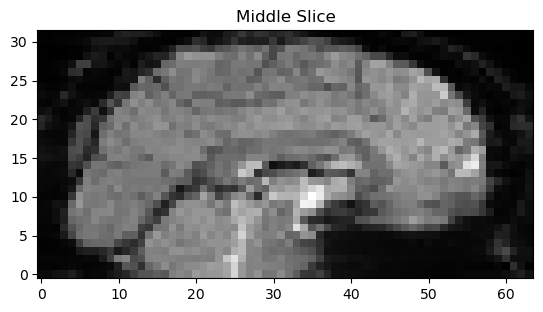

In [13]:
x = data.shape[0] // 2
y = data.shape[1] // 2
z = data.shape[2] // 2

plt.imshow(data[x, :, :, 0].T, cmap="gray", origin="lower")
plt.title("Middle Slice")
plt.show()

In [14]:
# %%
x_mid = data.shape[0] // 2
y_mid = data.shape[1] // 2
z_mid = data.shape[2] // 2
t = 0  # first time point

print(data.shape)

(64, 64, 32, 80)


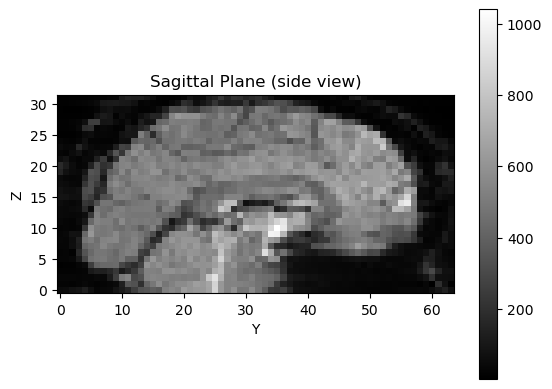

In [15]:
# Saggital plane
# %%
plt.imshow(data[x_mid, :, :, t].T, cmap="gray", origin="lower")
plt.title("Sagittal Plane (side view)")
plt.xlabel("Y")
plt.ylabel("Z")
plt.colorbar()
plt.show()

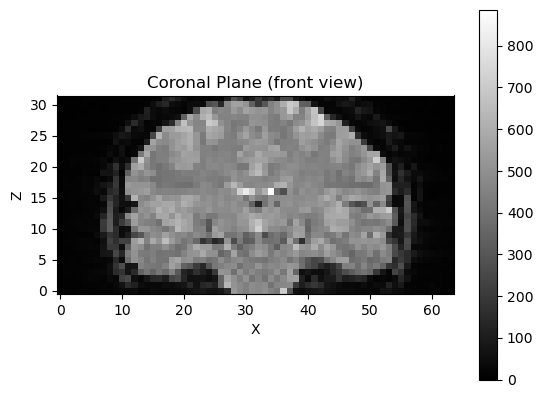

In [16]:
# Coronal Plane
# %%
plt.imshow(data[:, y_mid, :, t].T, cmap="gray", origin="lower")
plt.title("Coronal Plane (front view)")
plt.xlabel("X")
plt.ylabel("Z")
plt.colorbar()
plt.show()

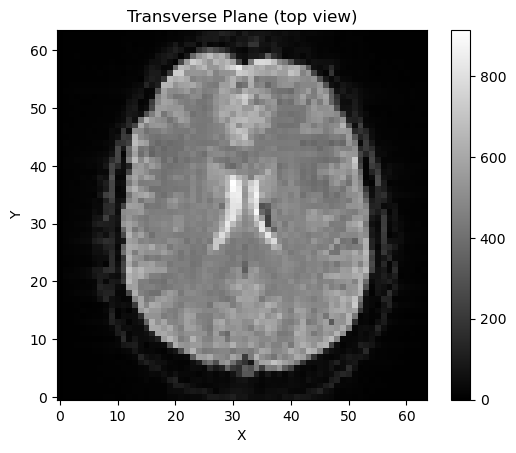

In [17]:
# Transverse Plane
# %%
plt.imshow(data[:, :, z_mid, t].T, cmap="gray", origin="lower")
plt.title("Transverse Plane (top view)")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()
plt.show()

In [18]:
# %%
import os

for root, dirs, files in os.walk("."):
    if "ols.csv" in files:
        print("FOUND:", os.path.join(root, "ols.csv"))

FOUND: ./data/ols.csv


In [19]:
# Loading CSV file
# %%
import pandas as pd

ols = pd.read_csv("./data/ols.csv", index_col="Vehicle")
print(ols.head())

                Length (m)  Payload Mass to LEO (kg) Origin  First Flight  \
Vehicle                                                                     
Falcon 9              70.0                     22800    USA        2010.0   
Falcon Heavy          70.0                     63800    USA        2018.0   
Atlas V               62.5                     13550    USA        2002.0   
Delta IV Heavy        72.0                     28370    USA        2002.0   
SLS Block 1           98.0                     95000    USA        2022.0   

                Initial Mass (kg)  
Vehicle                            
Falcon 9                   549000  
Falcon Heavy              1420000  
Atlas V                    335000  
Delta IV Heavy             733000  
SLS Block 1               2600000  


In [20]:
# %%
import sys
print(sys.executable)

/home/mukh11/.conda/envs/spacemed/bin/python


In [21]:
# Importing Seaborn
# %%
import seaborn as sns

<Axes: xlabel='Initial Mass (kg)', ylabel='Payload Mass to LEO (kg)'>

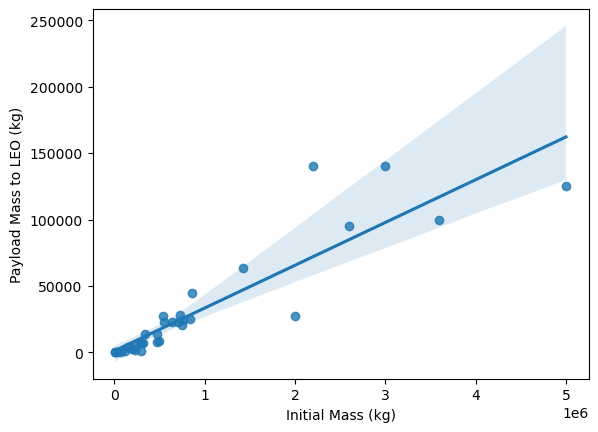

In [22]:
# Linear Correlation
# %%
sns.regplot(
    data=ols,
    x="Initial Mass (kg)",
    y="Payload Mass to LEO (kg)",
    order=1
)

<Axes: xlabel='Length (m)', ylabel='Payload Mass to LEO (kg)'>

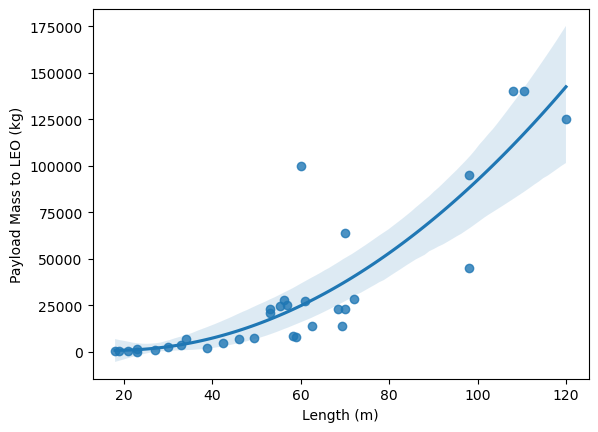

In [23]:
# Non-linear Correlation
# %%
sns.regplot(
    data=ols,
    x="Length (m)",
    y="Payload Mass to LEO (kg)",
    order=2
)

In [24]:
# Time Series
## Building Time Axis
# %%
nt = fmri.shape[-1]
sampling_rate = fmri.header.get_zooms()[-1]

times = np.arange(nt) * sampling_rate

In [25]:
# Picking meaningful voxels
# %%
voxel_1 = (19, 24, 25)
voxel_2 = (19, 25, 25)
voxel_3 = (40, 25, 25)

In [26]:
# Extracting time series
# %%
sig1 = data[voxel_1]
sig2 = data[voxel_2]
sig3 = data[voxel_3]

print(sig1.shape)  # should be (nt,)

(80,)


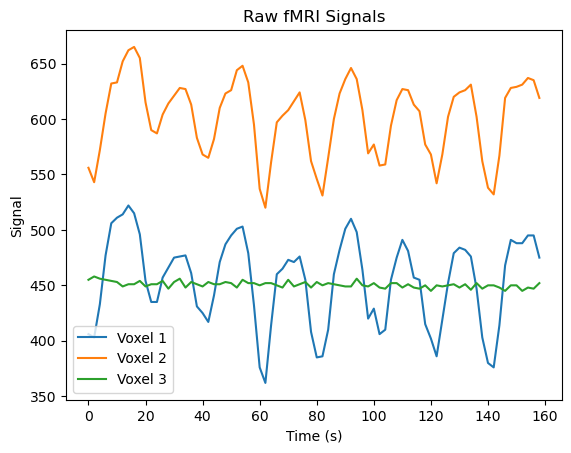

In [27]:
# Plotting time series raw signal
# %%
plt.plot(times, sig1, label="Voxel 1")
plt.plot(times, sig2, label="Voxel 2")
plt.plot(times, sig3, label="Voxel 3")

plt.xlabel("Time (s)")
plt.ylabel("Signal")
plt.title("Raw fMRI Signals")
plt.legend()
plt.show()

In [28]:
# Normalizing
# %%
def normalize(x):
    std = np.std(x)
    if std == 0:
        return np.zeros_like(x)   # safe fallback
    return (x - np.mean(x)) / std

sig1_n = normalize(sig1)
sig2_n = normalize(sig2)
sig3_n = normalize(sig3)

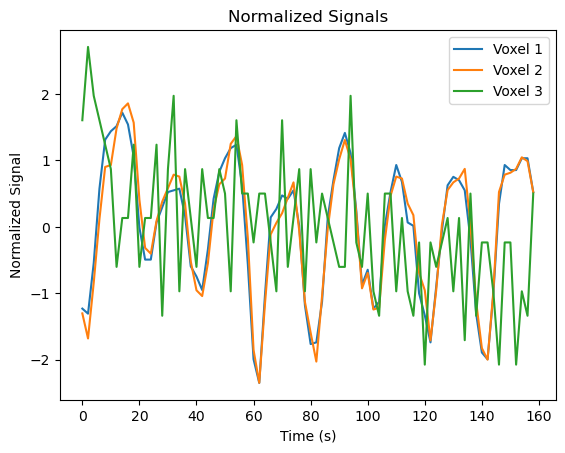

In [29]:
# Plotting Normalized
# %%
plt.plot(times, sig1_n, label="Voxel 1")
plt.plot(times, sig2_n, label="Voxel 2")
plt.plot(times, sig3_n, label="Voxel 3")

plt.xlabel("Time (s)")
plt.ylabel("Normalized Signal")
plt.title("Normalized Signals")
plt.legend()
plt.show()

In [30]:
# Spectral Analysis
## Priodogram
# %%
from scipy import signal as sg

freq1, power1 = sg.periodogram(sig1_n, fs=1/sampling_rate)
freq2, power2 = sg.periodogram(sig2_n, fs=1/sampling_rate)
freq3, power3 = sg.periodogram(sig3_n, fs=1/sampling_rate)

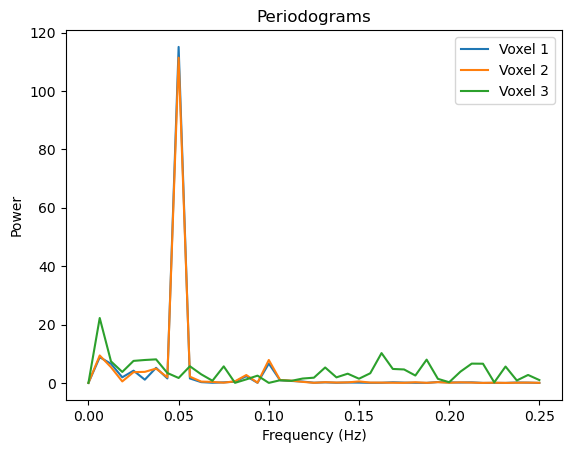

In [31]:
# Plotting 
# %%
plt.plot(freq1, power1, label="Voxel 1")
plt.plot(freq2, power2, label="Voxel 2")
plt.plot(freq3, power3, label="Voxel 3")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Periodograms")
plt.legend()
plt.show()

In [32]:
# Building Stimulus Signal
# %%
sone = np.array([1]*5 + [0]*5)

signal_input = np.tile(sone, int(np.ceil(nt / len(sone))))
signal_input = signal_input[:nt]

signal_input_n = normalize(signal_input)

In [33]:
# Cross Correlation
# %%
cross1 = sg.correlate(sig1_n, signal_input_n, mode="same")
cross2 = sg.correlate(sig2_n, signal_input_n, mode="same")
cross3 = sg.correlate(sig3_n, signal_input_n, mode="same")

lags = sg.correlation_lags(len(sig1_n), len(signal_input_n), mode="same")

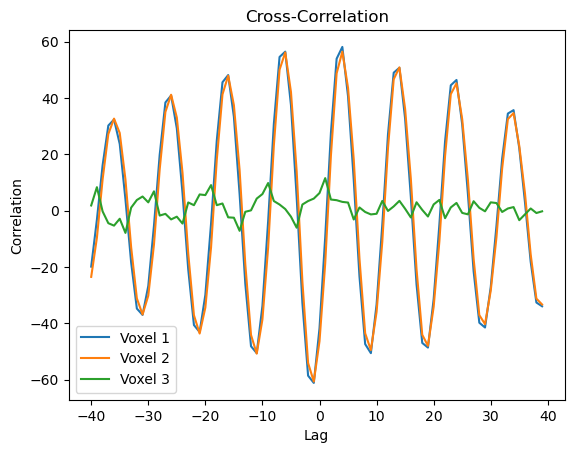

In [34]:
# Plotting Correlation
# %%
plt.plot(lags, cross1, label="Voxel 1")
plt.plot(lags, cross2, label="Voxel 2")
plt.plot(lags, cross3, label="Voxel 3")

plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.title("Cross-Correlation")
plt.legend()
plt.show()

In [35]:
# Finding Best Lag
# %%
print("Voxel 1 lag:", lags[np.argmax(cross1)])
print("Voxel 2 lag:", lags[np.argmax(cross2)])
print("Voxel 3 lag:", lags[np.argmax(cross3)])

Voxel 1 lag: 4
Voxel 2 lag: 4
Voxel 3 lag: 1


In [36]:
# Choosing a slice
# %%
z = data.shape[2] // 2   # middle slice

In [37]:
# Creating an empty result map
# %%
slice_shape = data.shape[:2]
activation_map = np.zeros(slice_shape)

In [38]:
# Looping over all voxels
# %%
signal_input_n = normalize(signal_input)

for x in range(data.shape[0]):
    for y in range(data.shape[1]):

        voxel_signal = data[x, y, z]

        if np.std(voxel_signal) == 0:
            continue

        voxel_signal_n = normalize(voxel_signal)

        cross = sg.correlate(voxel_signal_n, signal_input_n, mode="same")

        activation_map[x, y] = np.max(cross)

In [41]:
# Filtering
# %%
from scipy.ndimage import gaussian_filter

activation_smooth = gaussian_filter(activation_map, sigma=1)

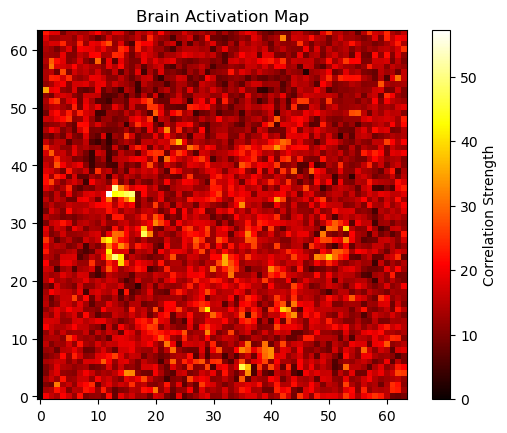

In [42]:
# Visualising activation map
# %%
plt.imshow(activation_map.T, cmap="hot", origin="lower")
plt.colorbar(label="Correlation Strength")
plt.title("Brain Activation Map")
plt.show()

In [40]:
# Wrapping into function
# %%
def compute_slice_activation(data, signal_input, z):
    activation_map = np.zeros(data.shape[:2])
    
    for x in range(data.shape[0]):
        for y in range(data.shape[1]):
            voxel_signal = normalize(data[x, y, z])
            signal_input_n = normalize(signal_input)
            
            cross = sg.correlate(voxel_signal, signal_input_n, mode="same")
            activation_map[x, y] = np.max(cross)
    
    return activation_map